# Modern Signal Analysis and Signal Processing · Homework Code (Python)

This notebook provides a Python translation of the original MATLAB implementations for both the Sampling Theorem and the Fourier Series Expansion used in modern signal analysis.

Modified by Haozheng Ji (jihz2023@mail.sustech.edu.cn) on March 18, 2026.

## Reference Implementations

- **sampling.m** — Haoran Meng, Fengjiang Ju & Wenyue Xia (Feb/18/2023)

- **FS_loop_HM.m** — Haoran Meng, Fengjiang Ju & Wenyue Xia (Feb/18/2023)

## Dependencies

- `numpy`
- `matplotlib`


In [212]:
import numpy as np 
import matplotlib.pyplot as plt 

# Sampling Theorem
 
## Nyquist Frequency
 
According to the Nyquist sampling theorem, to accurately reconstruct a signal, the sampling frequency (fs) must be at least twice the highest frequency present in the signal (fs ≥ 2 * f₀). 
 
If you sample below this rate, the sampled data cannot represent the original signal accurately due to aliasing effects. 

Note: Experimenting with both cosine and sine functions shows that insufficient sampling frequencies result in the inability to reconstruct the original oscillating waveform.

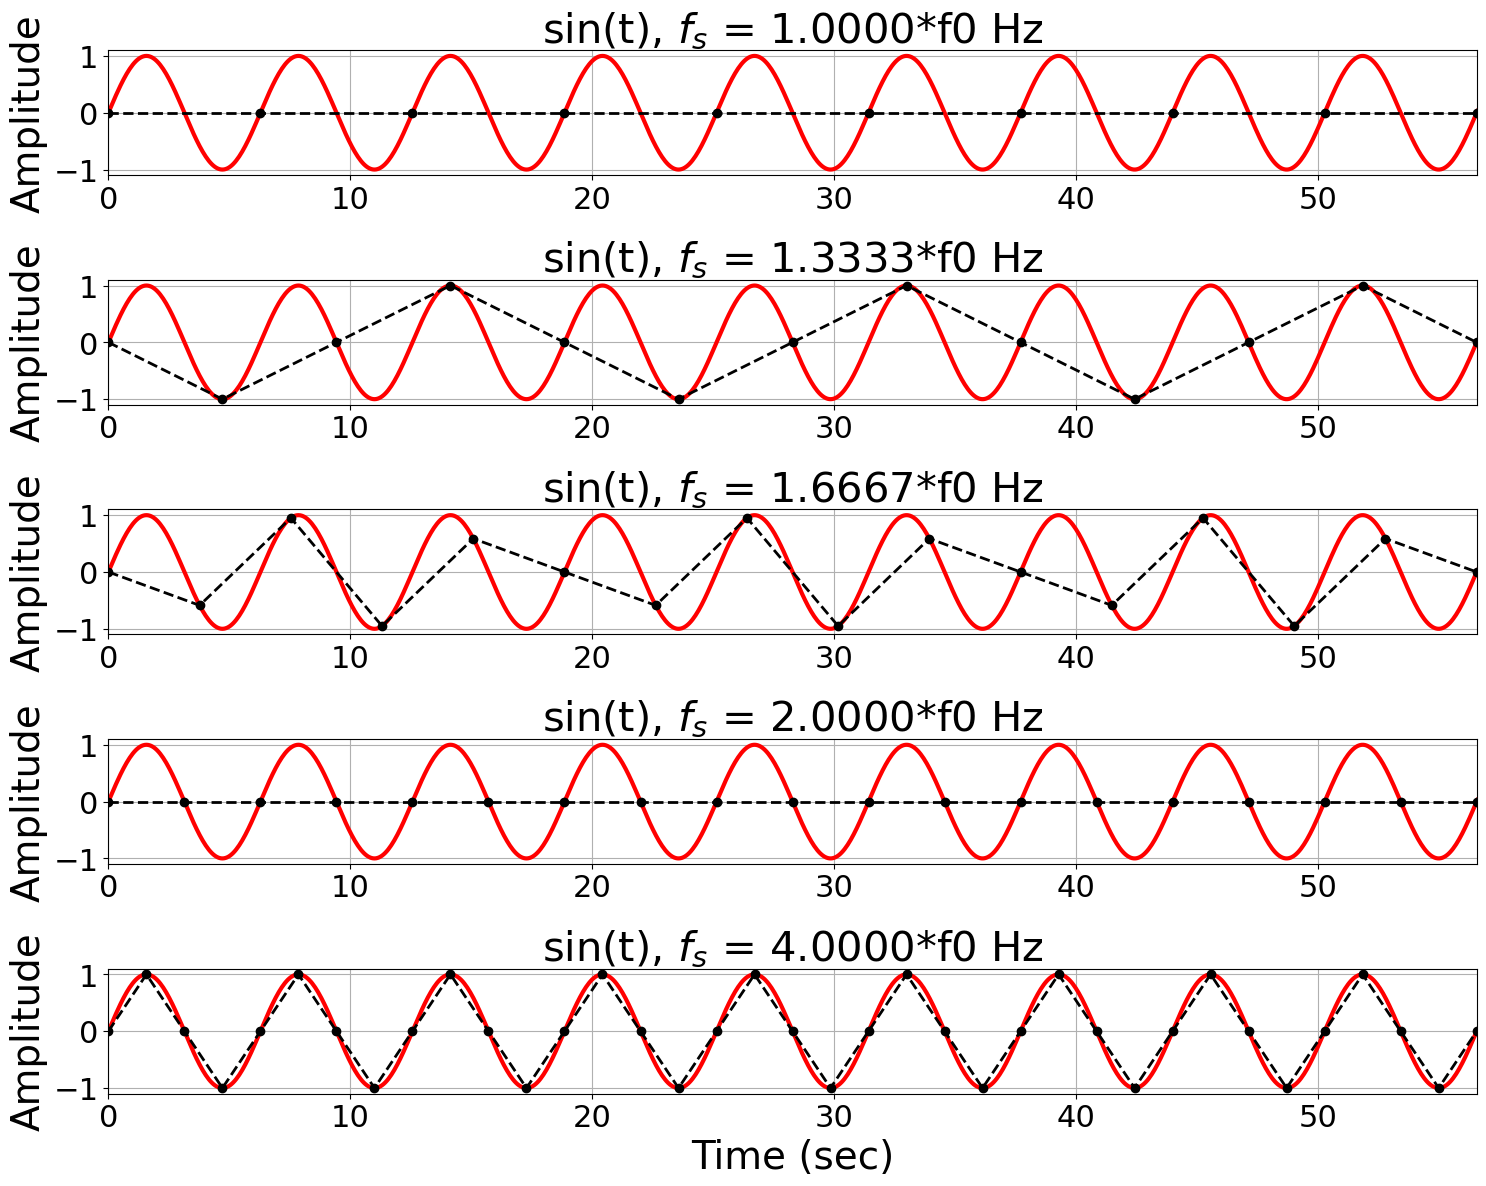

In [213]:
t_lin = np.linspace(0, 40*np.pi, 2000)  # time line
f0 = 1 / (2 * np.pi)           # function's oscillation frequency (Hz)
# Set sampling frequencies according to Nyquist: relative to new, much lower f0
Fs_scale = np.array([1, 4/3, 5/3, 2, 4])  # example: some below/at/above 2*f0
Fs=Fs_scale*f0
def f(t, f0=f0):
    # return np.sin(2 * np.pi * f0 * t)  # cosine function
    return np.sin(2 * np.pi * f0 * t) # sine function

y0 = f(t_lin)
nFs = len(Fs)

fig, axes = plt.subplots(nFs, 1, figsize=(15, 12))
for ii in range(nFs):
    T = 1 / Fs[ii]
    ts = np.arange(0, 40*np.pi, T)
    ys = f(ts)

    axes[ii].plot(t_lin, y0, 'r', linewidth=3)
    axes[ii].plot(ts, ys, 'o--k', linewidth=2, markerfacecolor='k', markeredgecolor='k')
    axes[ii].set_xlim([0, 18*np.pi])
    axes[ii].set_ylabel('Amplitude', fontsize=28)
    axes[ii].tick_params(labelsize=22)
    axes[ii].grid()
    if ii == nFs - 1:
        axes[ii].set_xlabel('Time (sec)', fontsize=28)
    axes[ii].set_title(
        f'sin(t), $f_s$ = {Fs_scale[ii]:.4f}*f0 Hz',
        fontsize=30
    )
plt.tight_layout(pad=1.2, h_pad=1.8)
plt.savefig('NyquistFrequency_sine.png', dpi=300)


## Aliasing
The following code and plot demonstrate that when we use a low sampling frequency to sample a high-frequency signal, the true frequency cannot be captured. This causes aliasing, where the sampled signal appears to have a different (lower) frequency than the original.

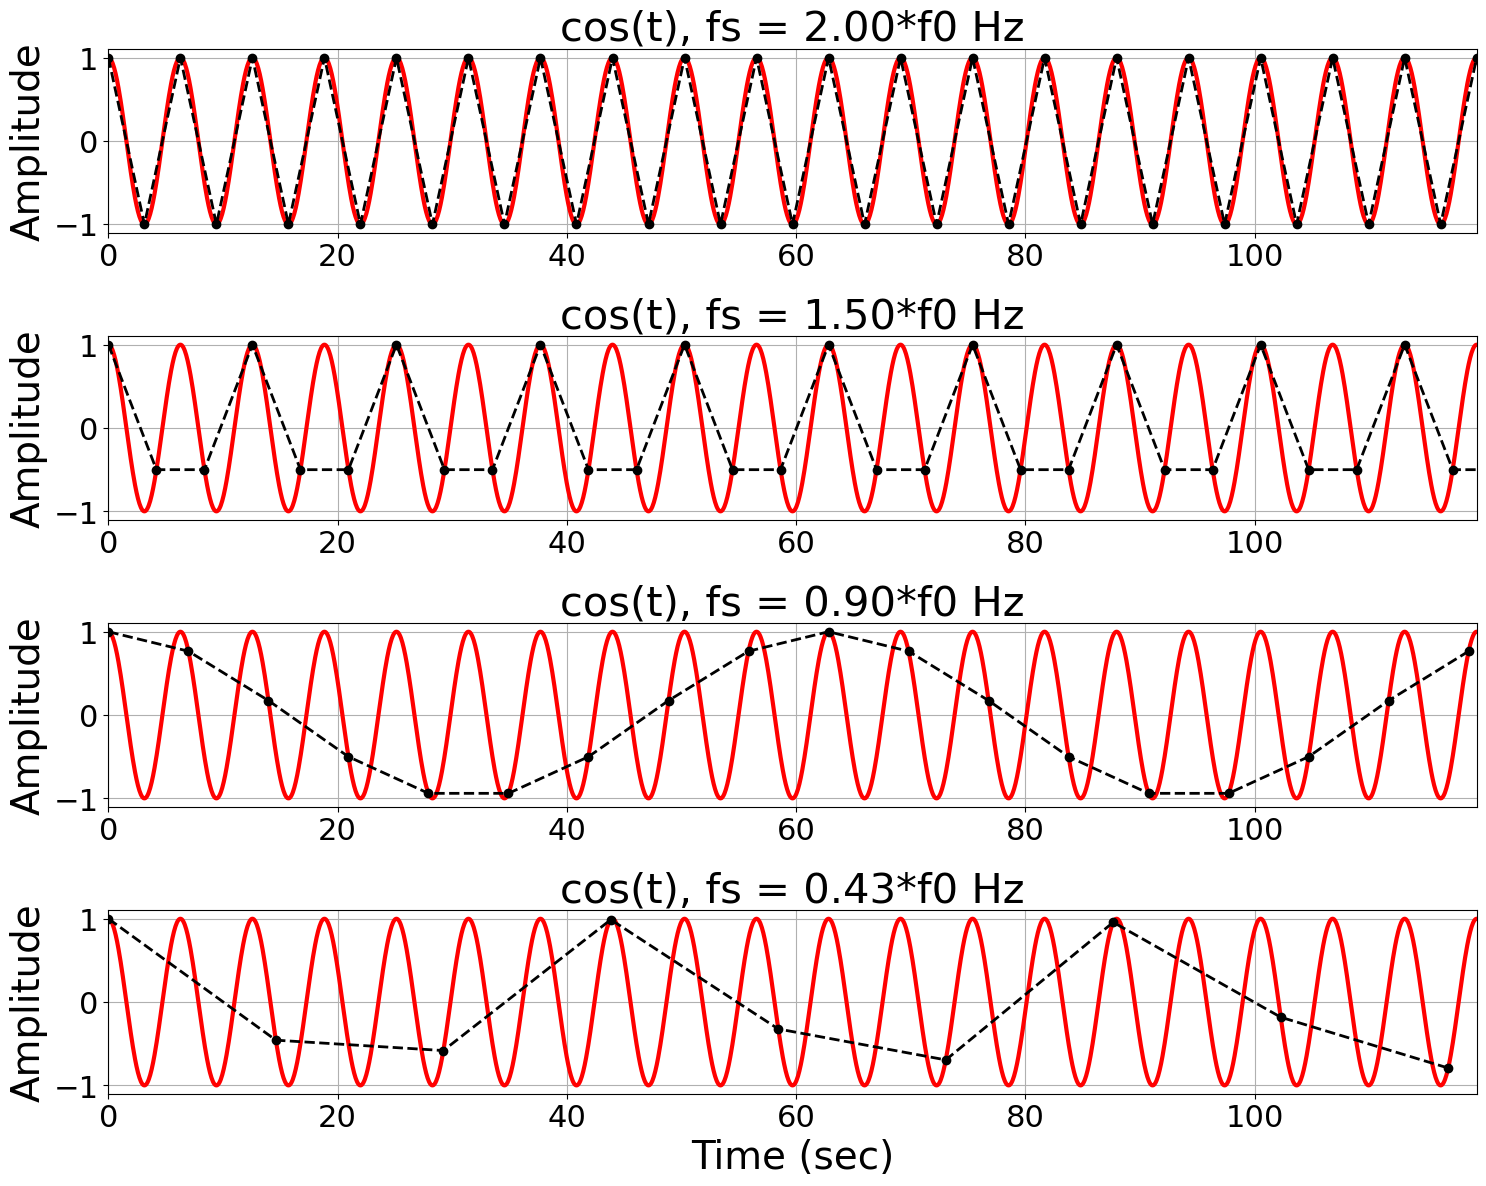

In [214]:
Fs_scale2=np.array([8,4.5,1.5,0.9])
Fs_scale2=np.array([2,1.5,0.9,0.43])

# Fs_scale2=np.array([0.21,0.15,0.11,0.03])
Fs=Fs_scale2*f0
def f(t,f0=f0):
    return np.cos(2*np.pi*f0*t)
y0=f(t_lin)
nFs=len(Fs)

fig,axes=plt.subplots(nFs,1,figsize=(15,12))
for ii in range(nFs):
    T=1/Fs[ii]
    ts = np.arange(0,40*np.pi,T)
    ys = f(ts)
    
    axes[ii].plot(t_lin,y0,'r',linewidth=3)
    axes[ii].plot(ts,ys,'o--k',linewidth=2,markerfacecolor='k',markeredgecolor='k')
    axes[ii].set_xlim([0,38*np.pi])
    axes[ii].set_ylabel('Amplitude',fontsize=28)
    axes[ii].tick_params(labelsize=22)
    axes[ii].grid()
    if ii==nFs-1:
        axes[ii].set_xlabel('Time (sec)',fontsize=28)
    axes[ii].set_title(f'cos(t), fs = {Fs_scale2[ii]:.2f}*f0 Hz',fontsize=30)
plt.tight_layout(pad=1.2,h_pad=1.8)
# plt.savefig('Aliasing_2.png',dpi=300)


# Fourier Series
In this section, we construct a periodic function `f0` over the interval `[0, T]` using a specified sampling period `dt`.

For a comprehensive introduction to the Fourier transform and its applications, refer to the document:
[From_Data_Fitting_to_Integral_Transforms (PDF)](https://github.com/JIhaozheng/SUSTech_ESS_Course_Materials/blob/main/ESS206%20Fundamentals%20of%20Signal%20Processing%20and%20Data%20Analysis/presentation/From_Data_Fitting_to_Integral_Transforms.pdf)

I attached a detailed derivation of how to calculate the Fourier series, as well as the Gram-Schmidt process for constructing orthogonal function sets using arbitary basis functions such as $\{e^{sx}\}$ and $\{x^s\}$.

In [ ]:
def fun(x):
    # exponential function
    # y = np.exp(np.pi*x)

    # sine function
    # y = np.sin(np.pi*x)

    # delta function
    # y = np.zeros_like(x)
    # y[np.abs(x - 0) < 1e-6] = 1 
    # y[np.abs(x) < dt/2] = 1/dt # is a better choice for delta function

    # square function
    # y = np.zeros_like(x)
    # y[x > 0] = 0.5
    # y[x < 0] = -0.5

    # ramp function
    y = 0.5 - np.abs(x)
    return y

flag = 1       # if flag = 1, compute the derivative; if flag = 2, compute the periodic integral
name = 'tri/tri_10' # directory of the saved figure
N = 10        # number of terms in the Fourier Series
T = 2          # period of the function
f = 1 / T      # fundamental frequency of the function
w0 = 2 * np.pi * f  # base frequency of fourier series
# for the delta function, you should use dt = 0.01 to see the obvious phenomenon
dt = 0.0001    # time step for sampling 
ts = -1        # start time 

# t0 = np.arange(ts, ts + T+dt, dt) 
t0 = np.linspace(-1, 1, int(T/dt) + 1)  # used to calculate the Fourier coefficients
f0 = fun(t0)         # float64 is generally sufficient; float128 may not be available on all platforms

t_lin = np.arange(-2 * T, 2 * T, dt)    # used to plot the periodic function
f_lin = fun(np.mod(t_lin - ts, T) + ts) # used to plot the periodic function




## Gibbs Phenomenon

For a detailed derivation and discussion of the Gibbs Phenomenon, please refer to **Chapter 3.1** for the theoretical proof of the Gibbs Phenomenon:
[Fundamentals of Signal Processing and Data Analysis - Homework 4 (PDF)](https://github.com/JIhaozheng/SUSTech_ESS_Course_Materials/blob/main/ESS206%20Fundamentals%20of%20Signal%20Processing%20and%20Data%20Analysis/homework/Fundamentals_of_Signal_Processing_and_Data_Analysis_Homework_4.pdf)

Understanding this section requires knowledge of fundamental concepts in complex numbers, series, and calculus.

## Explanation of numerical precision issues
In numerical calculations, the values of $a_n$ and $b_n$ (from $a_n \cos(ωt) + b_n\sin(ωt)$) may both approach zero. Due to numerical precision limits, an and bn can fluctuate near zero instead of being exactly zero. This may cause the computed phase to vary erratically and display meaningless results.

To avoid displaying meaningless phase values when the amplitude is negligible, the following filtering code can be used:

```python
if abs(amn[ii]) < 1e-12:
    phn[ii] = None
```

This sets the phase `phn[ii]` to `None` when the amplitude `amn[ii]` is close to zero.

If we are performing the integral of the function before calculating the Fourier series amplitudes, the threshold should be increased to ```1e-8``` for better filtering of negligible amplitudes.



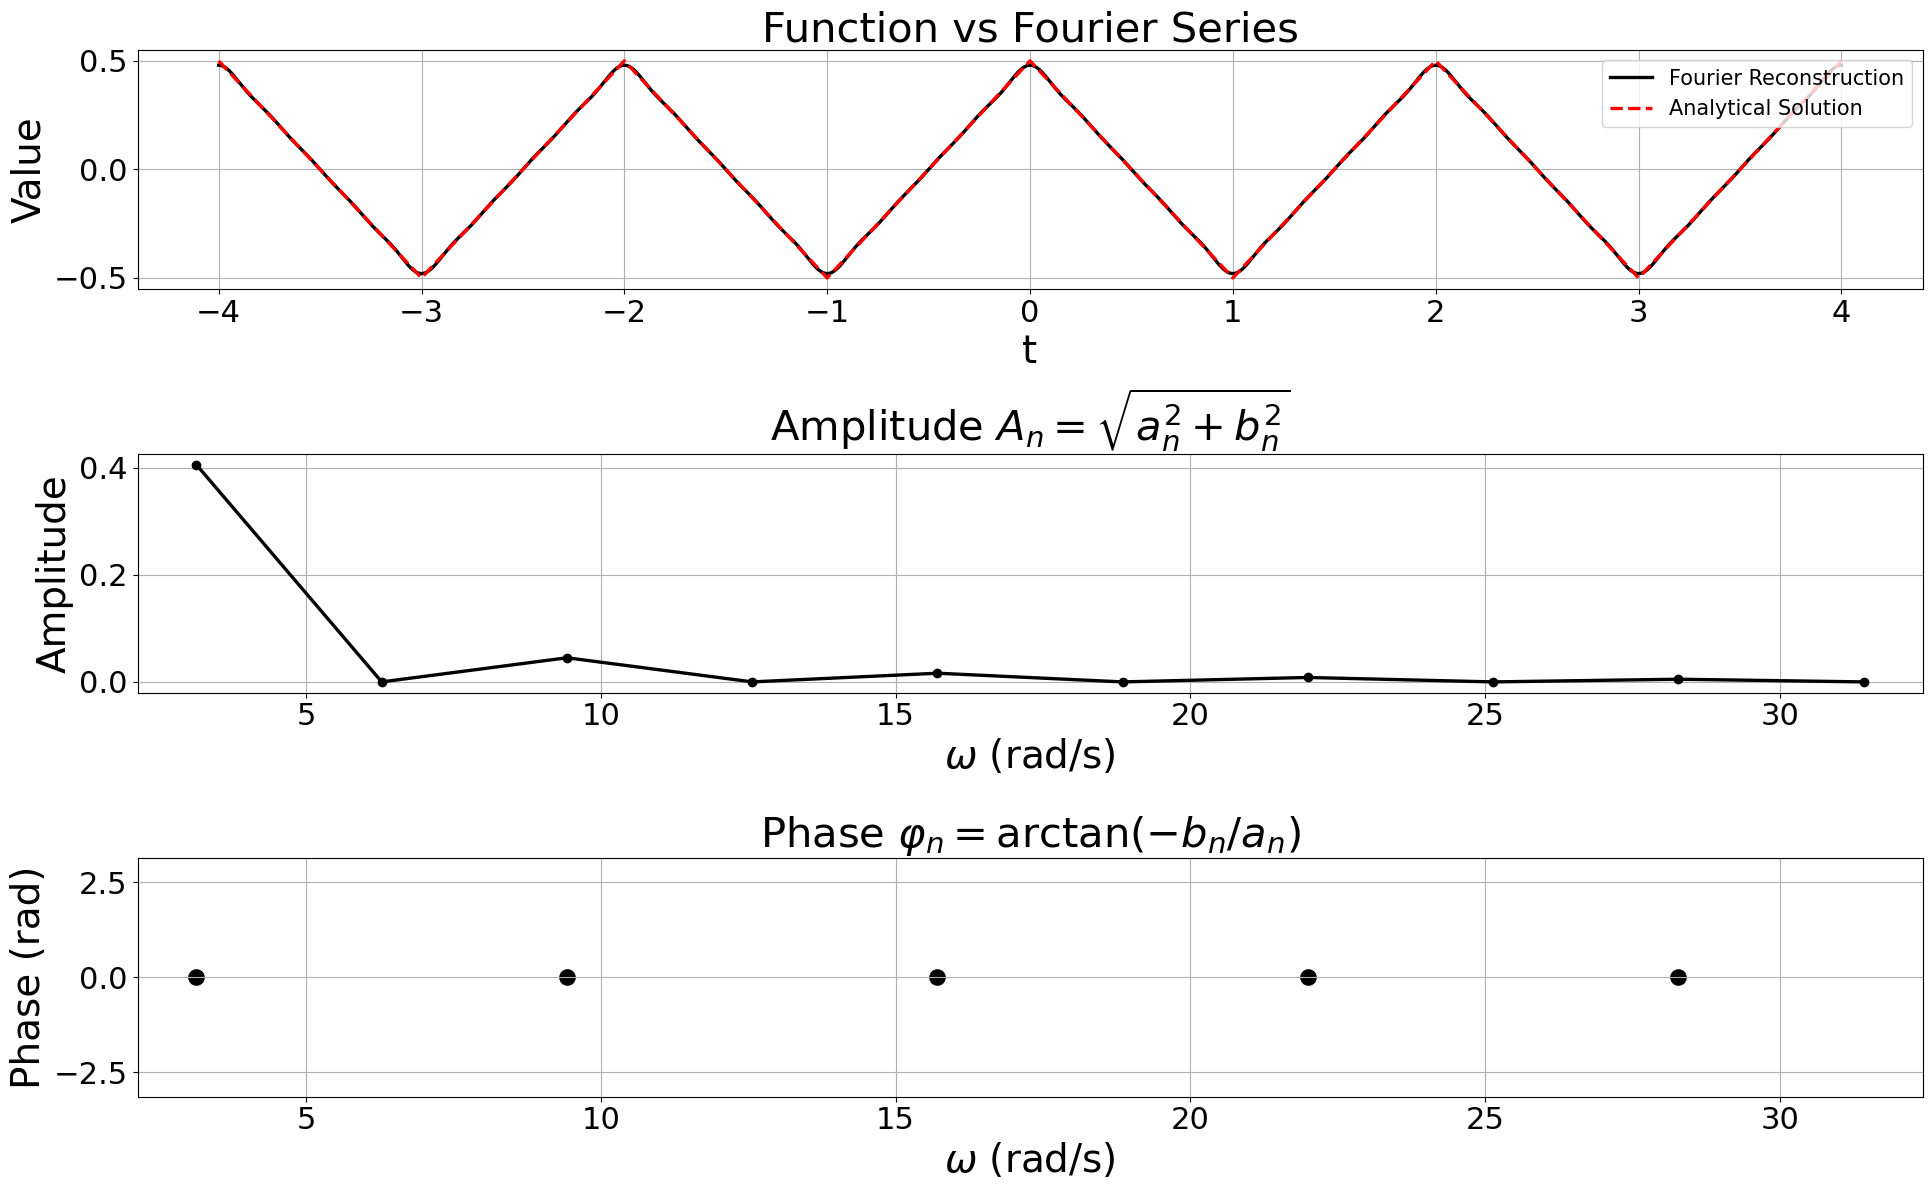

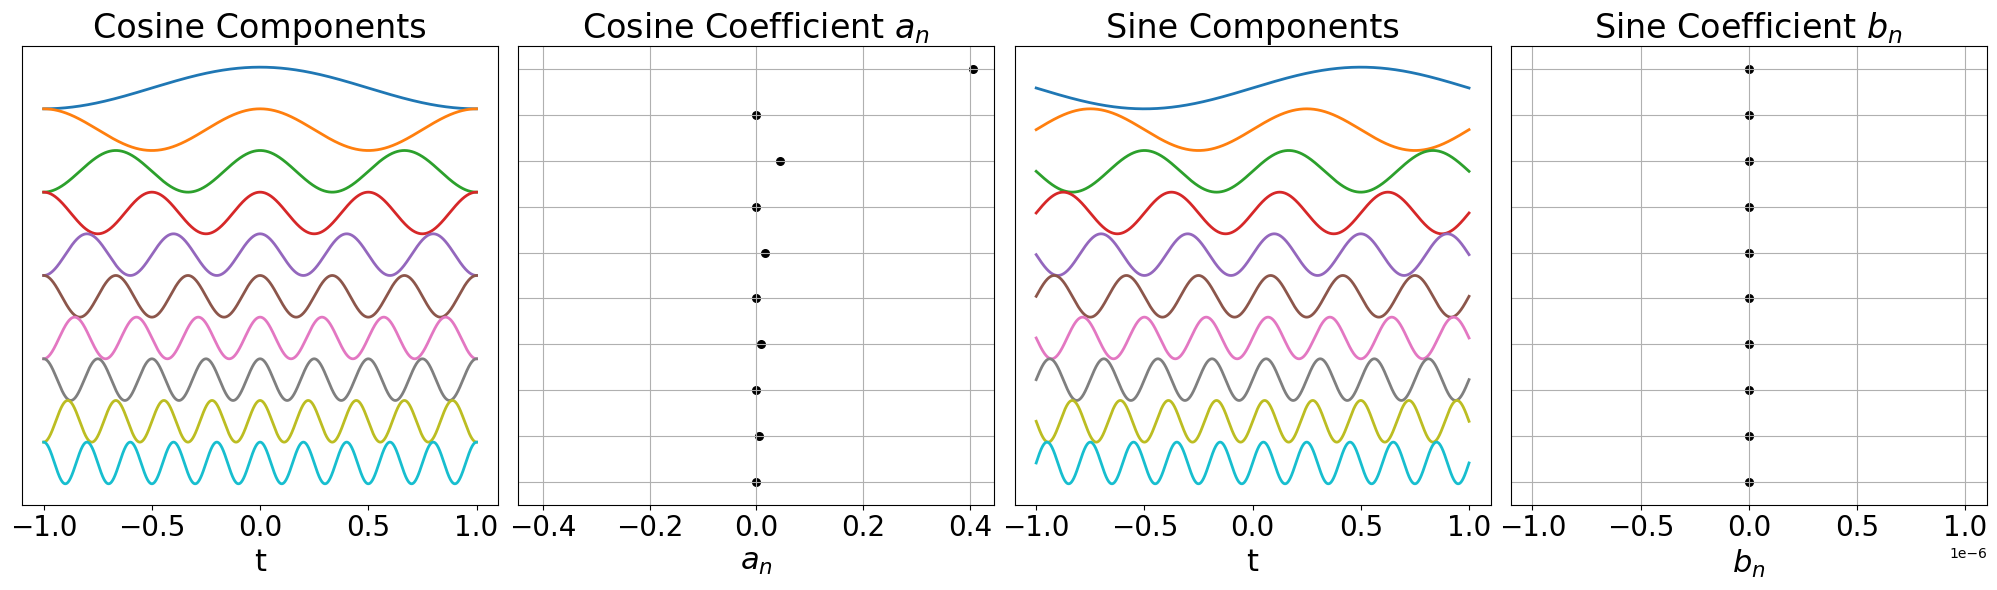

In [216]:
a0=np.trapz(f0*1,x=t0)/T
an=np.zeros(N+1)
an[0]=a0
bn=np.zeros(N+1)
phn=np.zeros(N+1)
amn=np.zeros(N+1)
amn[0]=abs(a0) 
phn[0]=np.arctan2(0,an[0])
S=a0*np.ones_like(t_lin)

for ii in range(1,N+1):
    # an[ii] = np.sum(f0 * np.cos(ii * w0 * t0)) * dt * 2 / T
    # bn[ii] = np.sum(f0 * np.sin(ii * w0 * t0)) * dt * 2 / T
    an[ii] = np.trapz(f0*np.cos(ii*w0*t0), x=t0)*2/T
    bn[ii] = np.trapz(f0*np.sin(ii*w0*t0), x=t0)*2/T
    # if abs(an[ii]) <= 1e-6:
    #     an[ii] = 0
    # if abs(bn[ii]) <= 1e-6:
    #     bn[ii] = 0
    phn[ii]=-np.arctan2(bn[ii],an[ii])
    amn[ii]=np.sqrt(an[ii]**2+bn[ii]**2)
    S=S+amn[ii]*np.cos(ii*w0*t_lin+phn[ii])
    if abs(amn[ii])<1e-12:
        phn[ii]=None
    # plt.plot(t_lin,S)
    # plt.show()
fig, axes = plt.subplots(3, 1, figsize=(20, 12))
axes[0].plot(t_lin, S, 'k', label='Fourier Reconstruction',linewidth=2.4)
# axes[0].plot(t_lin, fun(np.mod(t_lin-ts, T)+ts), '--', label='Analytical Solution', color='r',linewidth=2.4)
axes[0].plot(t_lin, f_lin, '--', label='Analytical Solution', color='r',linewidth=2.4)
axes[0].set_title('Function vs Fourier Series', fontsize=30)
axes[0].set_xlabel('t',fontsize=28)
axes[0].set_ylabel('Value',fontsize=28)
axes[0].tick_params(labelsize=22)
axes[0].legend(fontsize=15)
axes[0].legend(fontsize=15, loc='upper right')
axes[0].grid(True)
omega=np.arange(1,N+1)*w0
axes[1].plot(omega,amn[1:],'-o',color='k',linewidth=2.4)
axes[1].set_title('Amplitude $A_n=\\sqrt{a_n^2 + b_n^2}$', fontsize=30)
axes[1].set_xlabel('$\omega$ (rad/s)',fontsize=28)
axes[1].set_ylabel('Amplitude',fontsize=28)
axes[1].set_xlim([omega[0]-1,omega[-1]+1])
axes[1].tick_params(labelsize=22)
axes[1].grid(True)
axes[2].scatter(omega,phn[1:], color='k',s=120)
axes[2].set_title(f'Phase $\\varphi_n=\\arctan(-b_n/a_n)$', fontsize=30)
axes[2].set_xlabel('$\omega$ (rad/s)',fontsize=28)
axes[2].set_ylabel('Phase (rad)',fontsize=28)
axes[2].set_ylim(-np.pi,np.pi)
axes[2].set_xlim([omega[0]-1,omega[-1]+1])
axes[2].tick_params(labelsize=22)
axes[2].grid(True)

plt.tight_layout()
plt.subplots_adjust(left=0.10)
# plt.savefig(f"{name}_Fourier.png", dpi=300, bbox_inches="tight", pad_inches=0.15)
# plt.show()

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
for ii in range(1, N+1):
    axes[0].plot(t0, np.cos(ii*w0*t0)/2 + (N-ii), label=f'n={ii}',linewidth=2)
axes[0].set_title('Cosine Components',fontsize=24)
axes[0].set_yticklabels([])
axes[0].tick_params(axis='y', left=False, labelleft=False)
axes[0].set_xlabel('t',fontsize=22)
axes[0].tick_params(labelsize=20)
y_order = np.arange(1, N+1)
axes[1].scatter(an[1:], y_order, color='k', s=30)
axes[1].set_title('Cosine Coefficient $a_n$', fontsize=24)
axes[1].set_xlabel('$a_n$', fontsize=22)
axes[1].set_yticks(y_order)
axes[1].set_yticklabels([])
axes[1].tick_params(axis='y', left=False, labelleft=False)
axes[1].invert_yaxis()
axes[1].set_ylim(N + 0.5, 0.5)
ax1_max = float(np.max(np.abs(an[1:]))) if N >= 1 else 1.0
ax1_max = max(ax1_max, 1e-6)
axes[1].set_xlim(-1.1 * ax1_max, 1.1 * ax1_max)
axes[1].tick_params(labelsize=20)
axes[1].grid(True)
for ii in range(1, N+1):
    axes[2].plot(t0, np.sin(ii*w0*t0)/2 + (N-ii), label=f'n={ii}',linewidth=2)
axes[2].set_title('Sine Components',fontsize=24)
axes[2].set_yticklabels([])
axes[2].tick_params(axis='y', left=False, labelleft=False)
axes[2].set_xlabel('t',fontsize=22)
axes[2].tick_params(labelsize=20)
axes[3].scatter(bn[1:], y_order, color='k', s=30)
axes[3].set_title('Sine Coefficient $b_n$',fontsize=24)
axes[3].set_xlabel('$b_n$',fontsize=22)
axes[3].set_yticks(y_order)
axes[3].set_yticklabels([])
axes[3].tick_params(axis='y', left=False, labelleft=False)
axes[3].invert_yaxis() 
axes[3].set_ylim(N + 0.5, 0.5)
ax3_max = float(np.max(np.abs(bn[1:]))) if N >= 1 else 1.0
ax3_max = max(ax3_max, 1e-6)
axes[3].set_xlim(-1.1 * ax3_max, 1.1 * ax3_max)
axes[3].tick_params(labelsize=20)
axes[3].grid(True)
plt.tight_layout()
# plt.savefig(f"{name}_Fourier_Component.png",dpi=300)
plt.show()
# plt.close()



In [217]:
if flag!=0:
    if flag == 1:
        f0 = np.gradient(f0, dt)
        f_lin = np.gradient(f_lin, dt)
        omega_with0 = np.concatenate(([1e-12], omega))
        amn_analytical = amn * omega_with0
        phn_analytical = phn + np.pi/2
        # phn_analytical = (phn_analytical + np.pi) % (2 * np.pi) - np.pi
    if flag == 2:
        f0 = np.cumsum(f0) * dt
        f_lin = np.cumsum(f_lin) * dt
        omega_with0 = np.concatenate(([1e-12], omega))
        amn_analytical = amn / omega_with0
        phn_analytical = phn - np.pi/2
        phn_analytical = (phn_analytical + np.pi) % (2 * np.pi) - np.pi

    a0=np.trapz(f0*1,x=t0)/T
    an=np.zeros(N+1)
    an[0]=a0
    bn=np.zeros(N+1)
    phn=np.zeros(N+1)
    amn=np.zeros(N+1)
    amn[0]=abs(a0) 
    phn[0]=np.arctan2(0,an[0])
    S=a0*np.ones_like(t_lin)

    for ii in range(1,N+1):
        an[ii] = np.sum(f0 * np.cos(ii * w0 * t0)) * dt * 2 / T
        bn[ii] = np.sum(f0 * np.sin(ii * w0 * t0)) * dt * 2 / T
        # if abs(an[ii]) <= 1e-16:
        #     an[ii] = 0
        # if abs(bn[ii]) <= 1e-16:
        #     bn[ii] = 0
        phn[ii]=-np.arctan2(bn[ii],an[ii])
        amn[ii]=np.sqrt(an[ii]**2+bn[ii]**2)
        S=S+amn[ii]*np.cos(ii*w0*t_lin+phn[ii])
        if abs(amn[ii])<1e-8:
            phn[ii]=None
        # plt.plot(t_lin,S)
        # plt.show()
    fig, axes = plt.subplots(3, 1, figsize=(20, 12))
    axes[0].plot(t_lin, S, 'k', label='Fourier Reconstruction',linewidth=2.4)
    # axes[0].plot(t_lin, fun(np.mod(t_lin-ts, T)+ts), '--', label='Analytical Solution', color='r',linewidth=2.4)
    axes[0].plot(t_lin, f_lin, '--', label='Analytical Solution', color='r',linewidth=2.4)
    axes[0].set_title('Function vs Fourier Series', fontsize=30)
    axes[0].set_xlabel('t',fontsize=28)
    axes[0].set_ylabel('Value',fontsize=28)
    axes[0].tick_params(labelsize=22)
    axes[0].legend(fontsize=15, loc='upper right')
    axes[0].grid(True)
    omega=np.arange(1,N+1)*w0
    axes[1].plot(omega,amn[1:],'-o',color='k',linewidth=2.4,label="numerical")
    axes[1].plot(omega,amn_analytical[1:],'--o',color='r',linewidth=2.4,label="analytical")
    axes[1].set_title('Amplitude $A_n=\\sqrt{a_n^2 + b_n^2}$', fontsize=30)
    axes[1].set_xlabel('$\omega$ (rad/s)',fontsize=28)
    axes[1].set_ylabel('Amplitude',fontsize=28)
    axes[1].set_xlim([omega[0]-1,omega[-1]+1])
    axes[1].tick_params(labelsize=22)
    axes[1].legend(fontsize=15, loc='upper right')
    axes[1].grid(True)
    axes[2].scatter(omega,phn[1:], color='k',s=120,label="numerical")
    axes[2].scatter(omega, phn_analytical[1:], color='r', label="analytical")
    axes[2].set_title(f'Phase $\\varphi_n=\\arctan(-b_n/a_n)$', fontsize=30)
    axes[2].set_xlabel('$\omega$ (rad/s)',fontsize=28)
    axes[2].set_ylabel('Phase (rad)',fontsize=28)
    axes[2].set_ylim(-np.pi,np.pi)
    axes[2].set_xlim([omega[0]-1,omega[-1]+1])
    axes[2].tick_params(labelsize=22)
    axes[2].legend(fontsize=15, loc='upper right')
    axes[2].grid(True)

    plt.tight_layout()
    plt.subplots_adjust(left=0.10)
    # if flag==1:
    #     plt.savefig(f"{name}_deriative_Fourier.png", dpi=300, bbox_inches="tight", pad_inches=0.15)
    # if flag==2:
    #     plt.savefig(f"{name}_integral_Fourier.png", dpi=300, bbox_inches="tight", pad_inches=0.15)

    # plt.show()


